# Lesson 2. Inside the PID balancing loop

In Lesson 1 you watched a bicycle fall over even though its balancing loop was switched on. You then found that changing a single number, the D gain `pid_kd_roll`, changed whether it fell. You also saw that forward speed alone does not keep a bicycle upright: something has to steer.

In this lesson we open up that balancing loop and look at how it actually decides how to steer. Here is the plan:

1. Go through the three parts of PID one at a time, using the bicycle as the example, until each one makes intuitive sense.
2. Work through one moment of a ride with real numbers, so that you can see exactly how much each part contributes.
3. Take a short look at the second, smaller loop that lives inside the steering motor.
4. Ride the bicycle with a new settings file, `configs/tutorial.yaml`, and see whether its gains are good enough.

About that new file: Lesson 1 used `new_bike.yaml` and changed only its D gain. `tutorial.yaml` is a separate file with its own starting numbers. It is the file you will improve yourself in Lesson 3.

We will keep using the ideas from Lesson 1: the physics engine, the free-body diagram, gains, and the difference between the physics engine (the world) and the balancing loop (the rider).

As before, work from top to bottom. Read the text cells, and run each code cell (the ones with `[ ]`) with Shift+Enter.

## Glossary

Four more ideas come up in this lesson.

### Target and error

The **target** is the value we want. Engineers also call it the **setpoint**. For our bicycle, the target lean is always 0°, perfectly upright.

The **error** is how far the bicycle is from that target. It is worked out as *target minus measured value*. For example, if the bicycle is leaning +3°, the error is 0° − (+3°) = −3°. A large error means the bicycle is far from upright, and an error of zero means it is exactly on target. Every part of PID starts from this error.

### Steer rate, radians and rad/s

The balancing loop does not command a handlebar angle, and it does not command the motor's twist directly. It commands a **steer rate**: how fast the handlebars should turn.

The program measures angles in **radians** rather than degrees. A radian is simply another unit for angles, in the same way that kilometers and miles are two units for distance. One full turn is 360°, which is about 6.28 radians, so 1 radian is about 57°. A steer rate of 1 rad/s (one radian per second) therefore means "turn the handlebars about 57° every second". A positive steer rate turns the handlebars one way, and a negative steer rate turns them the other way.

### Steer term

Besides P, I and D, the balancing loop adds one more small piece. P, I and D all react to the bicycle's *lean*. The steer term reacts to the *handlebars*. If they have drifted away from pointing straight ahead, it adds a gentle pull back toward straight. Without it, the handlebars could slowly wander off to one side. Its gain is `pid_kp_steer`.

The steer term is not a fourth letter of PID. Think of it as a helper that works alongside PID.

### Saturation

Every real motor has limits. However hard the loop asks, the handlebars cannot turn faster than a certain speed. So the program caps the steer rate command at a maximum, which is 12 rad/s in these settings. When the command reaches that cap, we say it is **saturated**: asking for more changes nothing, like a volume knob that is already turned all the way up. On a graph, saturation shows up as a line that runs flat along a ceiling or a floor.

## Step 1. Start the lesson

As in Lesson 1, the first code cell prepares the notebook. It finds the project folder and loads the tools for drawing graphs.

Run the next cell now. When it finishes, check the line that begins with `project_root:`. It shows the folder this lesson is working from, and it should end in `bike_mujoco_sim`.

In [1]:
import os
import sys

def choose_mujoco_gl(platform, display, existing):
    if existing:
        return existing
    if str(platform).startswith("linux") and not display:
        return "egl"
    return None

chosen = choose_mujoco_gl(sys.platform, os.environ.get("DISPLAY"), os.environ.get("MUJOCO_GL"))
if chosen and "MUJOCO_GL" not in os.environ:
    os.environ["MUJOCO_GL"] = chosen

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

from sim.config import load_config
from sim.loop import make_sim, run_headless, summarize
from sim.pid_controller import RollSteerPID, apply_speed_refs

np.set_printoptions(precision=4, suppress=True)
print("project_root:", project_root)
print("platform:", sys.platform, "MUJOCO_GL:", os.environ.get("MUJOCO_GL", "(unset)"))


from sim.sensors import wrap_angle


project_root: /home/lmbike2/bike-workshop/bike_mujoco_sim
platform: linux MUJOCO_GL: (unset)


## The three parts of PID

Lesson 1 told you that the balancing loop is a **PID controller**, and that the letters stand for **P**roportional, **I**ntegral and **D**erivative. Each letter is a different way of looking at the same error, and each produces its own piece of the steering command. The loop then adds the pieces together to get the final command.

A handy way to remember the three parts is by time:

- P looks at the **present**: how big the error is right now.
- I looks at the **past**: how long the error has lasted.
- D looks toward the **future**: how fast the error is changing, and so where it is heading.

For each part below, we first describe the idea using the bicycle, and then name the setting that controls it.

### P, proportional: the present

The proportional part looks only at the error right now. "Proportional" means "in step with": this piece of the command is the error multiplied by a gain, so twice the lean gives twice the correction. If the bicycle is leaning 2°, P asks for a small turn of the handlebars. If a bump knocks it to 10°, P asks for a turn five times as big.

This is the spring from Lesson 1 again. The farther the bicycle is pushed away from upright, the harder P pushes it back. And like a spring, P has no memory, and it does not notice whether the lean is growing or shrinking. It only knows the lean at this moment.

The gain that sets how stiff this spring is, is `pid_kp_roll`. The P piece of the command is:

P piece = `pid_kp_roll` × error

### I, integral: the past

Imagine a heavy bag hanging off one side of the bicycle. It keeps dragging the bicycle toward that side. P pushes back, but suppose the bag is heavy enough that P's push only balances it while the bicycle is still leaning 1°. The bicycle settles at 1° and stays there.

P is satisfied with that. A 1° lean always gives the same small push, and nothing makes P push any harder. The lean simply never goes away.

The integral part solves this by remembering. It keeps a **running total** of the error. A lean that lasts keeps adding to the total, so the total keeps growing, and the I piece of the command grows with it. Eventually the extra steering is enough to bring the bicycle all the way back to 0°. That is why a running total is useful: a small lean that refuses to go away is exactly the kind of error that a steadily growing command can remove.

How does a computer keep a running total? The balancing loop does not run continuously. It wakes up at regular moments, does its calculation, sends a command, and then waits for the next moment. In these settings it wakes up 50 times every second, which is once every 0.02 seconds. (This interval is the setting `control_dt`.) Each time it wakes, it adds error × 0.02 seconds to the running total. A lean that lasts for one second therefore adds fifty small pieces into the total, which builds up into a noticeable amount.

The gain that sets how strongly this memory acts is `pid_ki_roll`. The I piece of the command is:

I piece = `pid_ki_roll` × running total

If `pid_ki_roll` is 0, the memory is switched off and I adds nothing.

### D, derivative: the future

"Derivative" is the mathematical name for *how fast something is changing*. Here it means how fast the lean is changing, which is called the **roll rate**. It is measured in degrees (or radians) per second.

Why does the roll rate matter? Suppose the bicycle is leaning only 3°, but it is tipping over at 20° every second. P sees only the 3° and asks for a small correction. But a quarter of a second later the bicycle will be at 8°, and soon after that it will be past saving. Waiting for the angle to become large means waiting too long. D looks at the roll rate instead, sees that the bicycle is falling fast, and reacts strongly straight away. In that sense it looks into the future: a fast tip now means a big lean very soon.

D also helps in the other direction. If the bicycle is swinging back toward upright very quickly, it could overshoot 0° and fall over the other side. D sees that fast swing and slows it down. Either way, D acts like a **brake** on fast motion. It does not care where the bicycle is, only how fast its lean is changing.

Recall the two bicycles from Lesson 1, both leaning 5°, one drifting slowly and one falling fast. P treats them the same. D is the only part that tells them apart. That is why setting the D gain to 1 in Lesson 1 left the bicycle with such a weak response to a fast fall.

The gain that sets how strong this brake is, is `pid_kd_roll`. The D piece of the command is:

D piece = `pid_kd_roll` × (−roll rate)

The minus sign makes the brake work against the direction the bicycle is tipping.

### Putting the pieces together

Every 0.02 seconds, the loop adds up all the pieces:

steering command = P piece + I piece + D piece + steer term

It then caps the result at the maximum steer rate. That cap is the saturation from the glossary.

Let's try it on one example moment, which the next step works through in numbers. The bicycle is leaning +3°, it is still tipping further at +20° each second, and the handlebars are pointing straight ahead.

- The error is target minus lean: 0° − (+3°) = −3°.
- P works from that −3° error.
- I has only just started. This is its very first moment, so its running total is tiny.
- D works from the +20° per second roll rate.
- The steer term is zero, because the handlebars are already straight.

The negative sign on the error tells you that the command will work to *undo* the positive lean, which is exactly what we want.

## Step 2. The same moment, in numbers

The next cell takes the example moment from above: the bicycle leaning +3°, tipping at +20° per second, handlebars straight. It calculates each piece of the command using the gains in `configs/tutorial.yaml`.

Before multiplying, the cell converts the angles from degrees to radians, because the program's gains are designed to work with radians. Every printed number is a steer rate in rad/s: how fast that piece is asking the handlebars to turn. As a reminder, 1 rad/s is about 57° per second.

The cell prints these lines:

- **P term**: the piece from the present lean of +3°.
- **I term**: the piece from the running total. This is the very first moment, so the total has had only 0.02 seconds to build up. If this file's I gain is 0, this line is exactly zero.
- **D term**: the piece from the roll rate of +20° per second.
- **steer term**: the pull toward straight handlebars. They are already straight, so this line is zero.
- **clipped command**: the four pieces added together and then capped at the maximum steer rate. "Clipped" is another word for capped. This is the command the loop actually sends.

The final line, starting with `library step()`, asks the project's real balancing-loop code (in `sim/pid_controller.py`) to do the same calculation. It should print the same number as the clipped command. That match shows that the hand calculation in this cell is exactly what the bicycle's program does.

Simply run the cell. Then look at which piece is the largest. A negative sign on a piece means it pushes to undo the positive lean.

In [2]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
pid = RollSteerPID(
    kp_roll=cfg.pid_kp_roll,
    ki_roll=cfg.pid_ki_roll,
    kd_roll=cfg.pid_kd_roll,
    kp_steer=cfg.pid_kp_steer,
    max_steer_velocity=cfg.max_steer_velocity,
    integral_limit=cfg.pid_integral_limit,
)

roll = float(np.deg2rad(3.0))
roll_rate = float(np.deg2rad(20.0))
steer = 0.0
dt = cfg.control_dt
e_roll = 0.0 - roll
e_steer = 0.0 - wrap_angle(steer)
pid.integral = 0.0
pid.integral = max(-pid.integral_limit, min(pid.integral_limit, pid.integral + e_roll * dt))
p_term = pid.kp_roll * e_roll
i_term = pid.ki_roll * pid.integral
d_term = pid.kd_roll * (-roll_rate)
s_term = pid.kp_steer * e_steer
raw = p_term + i_term + d_term + s_term
cmd = float(max(-pid.max_steer_velocity, min(pid.max_steer_velocity, raw)))
print("roll = +3 deg, roll_rate = +20 deg/s")
print(f"  P term {p_term:+.3f} rad/s")
print(f"  I term {i_term:+.3f} rad/s")
print(f"  D term {d_term:+.3f} rad/s")
print(f"  steer term {s_term:+.3f} rad/s")
print(f"  clipped command {cmd:+.3f} rad/s")
pid.integral = 0.0
print(f"library step() {pid.step(steer=steer, roll=roll, roll_rate=roll_rate, dt=dt):+.3f} rad/s")


roll = +3 deg, roll_rate = +20 deg/s
  P term -0.262 rad/s
  I term -0.000 rad/s
  D term -2.094 rad/s
  steer term +0.000 rad/s
  clipped command -2.356 rad/s
library step() -2.356194490192345


## Step 3. The smaller loop inside the steering motor

The balancing loop's output is a steer rate: "turn the handlebars this fast". But a motor does not understand "this fast". A motor only understands how hard to twist, which is its torque. Something has to turn the requested speed into a twist. That is the job of a second, smaller control loop inside the steering motor.

This inner loop works in the same way as the balancing loop, but it measures something different. At every moment it:

1. Compares the steer rate the balancing loop asked for with how fast the handlebars are actually turning. The difference is this inner loop's own error.
2. Adds that error to its own running total.
3. Sets the motor torque to `steer_kp` × error + `steer_ki` × running total.

You may recognize these as the P and I ideas again, this time applied to handlebar speed instead of lean. When one loop feeds its output into another loop like this, the arrangement is called a **cascade**. The outer loop (balancing) decides *what* the handlebars should do, and the inner loop (motor) works out *how* to make them do it.

For the whole course, keep `steer_kp` and `steer_ki` at their printed values. They have already been chosen so that the motor follows its requests well. All of your changes will be to the balancing-loop gains, which are the ones whose names start with `pid_`.

There is no code to run in this step.

## Step 4. Open this lesson's settings file

This lesson rides the bicycle with `configs/tutorial.yaml`. This is a different file from `new_bike.yaml`, which Lesson 1 used, and it has its own set of balancing-loop gains. These gains have deliberately not been tuned yet, because this is the file you will improve in Lesson 3.

The next cell loads the file and prints its gains on two lines. The first line, labeled `outer gains`, shows the four balancing-loop gains:

| Printed name | Setting in the file | What it does |
| --- | --- | --- |
| `kp_roll` | `pid_kp_roll` | P gain: how strongly to steer against the lean the bicycle has right now. |
| `ki_roll` | `pid_ki_roll` | I gain: how strongly to steer against a lean that has lasted. |
| `kd_roll` | `pid_kd_roll` | D gain: how strong the brake on a fast fall is. This is this file's own value, not the 1 from Lesson 1. |
| `kp_steer` | `pid_kp_steer` | Steer term gain: the gentle pull back toward straight handlebars. |

The second line, labeled `inner motor`, shows `steer_kp` and `steer_ki`, the gains of the motor loop from Step 3. Keep those as they are.

Run the cell and write down the four outer gains. You will need the D gain later, in the Questions.

In [3]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
print("loaded", os.path.relpath(tutorial_yaml, project_root))
print(
    "outer gains: kp_roll={:.4f} ki_roll={:.4f} kd_roll={:.4f} kp_steer={:.4f}".format(
        cfg.pid_kp_roll, cfg.pid_ki_roll, cfg.pid_kd_roll, cfg.pid_kp_steer
    )
)
print("inner motor: steer_kp={:.4f} steer_ki={:.4f}".format(cfg.steer_kp, cfg.steer_ki))


loaded configs/tutorial.yaml
outer gains: kp_roll=5.000 ki_roll=0.000 kd_roll=6.000 kp_steer=1.116
inner motor: steer_kp=0.0344 steer_ki=0.0213


## Step 5. Watch the ride, then draw it

Let's find out whether the gains in `tutorial.yaml` can balance the bicycle. There are two cells here. The first plays the ride in the 3D window. The second runs the same ride again without the window and draws it.

1. Run the first cell and watch the ride. Pay attention to the handlebars as well as the lean. Are they moving, trying to catch the bicycle?
2. Close the MuJoCo window when the ride is over. The cell finishes once the window is closed.
3. Run the second cell. It draws two graphs, one above the other, sharing the same time axis along the bottom.

The **upper graph** shows the bicycle's lean over time. Read it the same way as in Lesson 1: 0° is upright, and the dashed lines at +45° and −45° are the fall marks. If the lean crosses one of them, a dotted vertical line shows when that happened.

The **lower graph** is new. It shows the steering command the balancing loop sent at each moment: the steer rate in rad/s, from Step 2. A line at 0 means the loop was asking for no steering. A line away from 0 means the loop was asking the handlebars to turn, one way (positive) or the other way (negative). If the line runs flat along a ceiling or a floor, the command is saturated: the loop is asking for the maximum steer rate and cannot ask for more.

As you look at the graphs, try to answer two questions for yourself. During the first second, is the steering command doing anything, or is it sitting at 0? And does the lean cross 45°?

If the window cell stops with a message saying MuJoCo was already imported, use **Kernel → Restart Kernel**. Run the window cell again, then run the Step 1 cell once more before you run the graph cell.

In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, duration=6.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("gains from", os.path.relpath(tutorial_yaml, project_root))
print(f"pid_kp_roll {cfg.pid_kp_roll:.4f}  pid_ki_roll {cfg.pid_ki_roll:.4f}  pid_kd_roll {cfg.pid_kd_roll:.4f}")
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


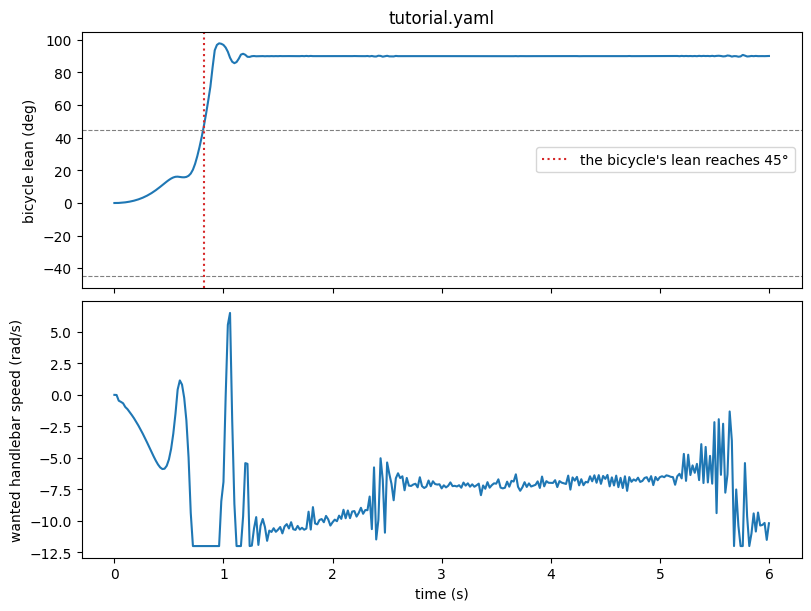

In [5]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, duration=6.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
history = run_headless(sim, duration=6.0)

time_s = np.asarray(history["time"], dtype=float)
roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
rate_cmd = np.asarray(history["steer_rate_ref"], dtype=float)
tip = np.where(np.abs(roll_deg) > 45.0)[0]
tip_t = float(time_s[tip[0]]) if len(tip) else None

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)
axes[0].plot(time_s, roll_deg)
axes[0].axhline(45, color="0.5", linestyle="--", linewidth=0.8)
axes[0].axhline(-45, color="0.5", linestyle="--", linewidth=0.8)
if tip_t is not None:
    axes[0].axvline(tip_t, color="C3", linestyle=":", label="the bicycle's lean reaches 45°")
    axes[0].legend()
axes[0].set_ylabel("bicycle lean (deg)")
axes[0].set_title("tutorial.yaml")
axes[1].plot(time_s, rate_cmd)
axes[1].set_ylabel("wanted handlebar speed (rad/s)")
axes[1].set_xlabel("time (s)")
plt.show()

if tip_t is None:
    raise RuntimeError("expected the bicycle's lean to pass 45°")


## Reading the two graphs

Read the two graphs together, moment by moment, because they describe the same ride.

Start at the left edge of the upper graph and follow the lean as time goes on. At any moment, look straight down at the lower graph to see what the balancing loop was asking for at that same moment. This is the most useful way to read a controller: put *what happened* (the lean) next to *what the controller tried to do about it* (the steering command).

Here are a few things worth checking:

- When the lean starts to move away from 0°, does the steering command respond straight away, or only later?
- Does the steering command ever run flat along the top or the bottom of its graph? If so, the loop was asking for all the steering it was allowed. What was the lean doing at that time?
- Compare the upper graph with the one you drew in Lesson 1. Did this file's gains keep the bicycle up longer or shorter than the D gain of 1 did there?

The window showed you the motion. These two graphs are that same ride, written down as numbers.

## Questions

These questions check that you can connect the calculation in Step 2 with the ride you just watched. Write your answers down before you run the next cell.

1. Look back at the numbers from Step 2, for the bicycle leaning +3° and tipping at +20° per second. Which piece was the largest: P, I, D, or the steer term? Why do you think that piece came out so much larger than the others?
2. Write down the D gain that Step 4 printed for `tutorial.yaml`. Now predict what happens with a larger D gain, `pid_kd_roll = 11` (the largest value you tried at the end of Lesson 1), while the other gains in `tutorial.yaml` stay as they are. Will the bicycle's lean cross 45°, or stay under 45°?

The next cell checks both answers:

- First, it prints which piece was the largest for the +3°, +20° per second moment. Compare that with your answer to question 1.
- Then it rides the bicycle without a window, using the D gain in `kd_try`, and prints the largest lean and whether it crossed 45°.

Run it twice:

1. Set `kd_try` to the D gain you wrote down from Step 4, and run the cell. The result should match the ride you just watched.
2. Change `kd_try` to `11.0` and run the cell again. Compare the result with your prediction.

In [6]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
roll = float(np.deg2rad(3.0))
roll_rate = float(np.deg2rad(20.0))
terms = {
    "P": abs(cfg.pid_kp_roll * (0.0 - roll)),
    "I": abs(cfg.pid_ki_roll * (0.0 - roll) * cfg.control_dt),
    "D": abs(cfg.pid_kd_roll * roll_rate),
    "steer": 0.0,
}
print("largest part for the bicycle leaned +3° and tipping at +20°/s:", max(terms, key=terms.get))

# kd_try is pid_kd_roll. Start with the derivative gain printed in Step 4, then try 11.
kd_try = 6.0
cfg = replace(cfg, pid_kd_roll=float(kd_try), duration=4.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
history = run_headless(sim, duration=4.0)
time_s = np.asarray(history["time"], dtype=float)
roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
tip = np.where(np.abs(roll_deg) > 45.0)[0]
tip_t = float(time_s[tip[0]]) if len(tip) else None
print(f"pid_kp_roll = {cfg.pid_kp_roll:.4f}, pid_kd_roll = {cfg.pid_kd_roll:.4f}")
print(f"largest lean of the bicycle = {float(np.max(np.abs(roll_deg))):.1f} degrees")
if tip_t is None:
    print("Result: the bicycle's lean stayed under 45°.")
else:
    print(f"Result: the bicycle's lean passed 45° at {tip_t:.2f} s.")


largest part for the bicycle leaned +3° and tipping at +20°/s: D


pid_kd_roll = 6.0
largest lean of the bicycle = 97.8 degrees
Result: the bicycle's lean passed 45° at 0.82 s.


## Discussion

Here are some questions students often ask after this lesson, with explanations.

### The bicycle still fell. Was the balancing loop doing anything at all?

Yes, and the lower graph shows it. The steering command moved away from 0 almost as soon as the ride started, and it may even have reached its ceiling, which means the loop was asking for all the steering it was allowed. The loop was trying hard. The problem is that, with the gains in this file, the steering it asked for did not catch the fall in time.

A working controller is not just one that is switched on. It is one whose gains are strong enough, in the right places, for the job.

### Why was the D piece so much bigger than the P piece in the example?

Look at the two inputs. The lean was only 3°, a small error. But the tipping speed was 20° every second, which is fast. D reacts to that speed, so it produced a large piece of the command. P reacts only to the small 3°, so it produced a small piece.

This is D doing its job: catching a fall that is still small but getting worse quickly. The I piece was tiny because it had only had one 0.02-second moment to build up its running total. If this file's I gain is 0, I adds nothing at all.

### Is there only one way a balancing loop can fail?

No. What you saw here is one kind of failure: the bicycle struggles for a moment, then leans over to one side and falls.

There is another kind you may meet later. If the P gain is much too high and there is not enough D gain to brake it, the loop over-corrects. It pushes the bicycle past upright, then over-corrects the other way, and the bicycle wobbles left and right with bigger and bigger swings. Both are failures of tuning, but they look very different on a graph, so it helps to recognize both.

### Which numbers am I allowed to change?

The four balancing-loop gains in `configs/tutorial.yaml`: `pid_kp_roll`, `pid_ki_roll`, `pid_kd_roll` and `pid_kp_steer`. Keep the motor loop's gains, `steer_kp` and `steer_ki`, as they are.

In Lesson 3 you will change the balancing-loop gains one at a time, following a simple method, until the bicycle stays up.